# Visualize Group Stage Predictions

Graphics and charts for the locked 72 group-stage predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions
predictions = pd.read_csv('../predictions/group_stage_predictions.csv')

print(f"Loaded {len(predictions)} group stage predictions")
print(f"\nGroups: {sorted(predictions['group'].unique())}")
print(f"\nFirst 5 predictions:")
print(predictions[['date', 'group', 'home_team', 'away_team', 'p_home_win', 'p_draw', 'p_away_win']].head())

Loaded 72 group stage predictions

Groups: ['Group A', 'Group B', 'Group C', 'Group D', 'Group E', 'Group F', 'Group G', 'Group H', 'Group I', 'Group J', 'Group K', 'Group L']

First 5 predictions:
         date    group       home_team               away_team  p_home_win  \
0  2026-06-11  Group A          Mexico            South Africa    0.494027   
1  2026-06-12  Group A  Korea Republic                 Czechia    0.420968   
2  2026-06-12  Group B          Canada  Bosnia and Herzegovina    0.364318   
3  2026-06-12  Group D   United States                Paraguay    0.428783   
4  2026-06-13  Group C           Haiti                Scotland    0.226151   

     p_draw  p_away_win  
0  0.278454    0.227518  
1  0.270580    0.308452  
2  0.290907    0.344775  
3  0.283706    0.287510  
4  0.237159    0.536688  


## 1. Distribution of Predicted Probabilities

Saved: 01_probability_distributions.png


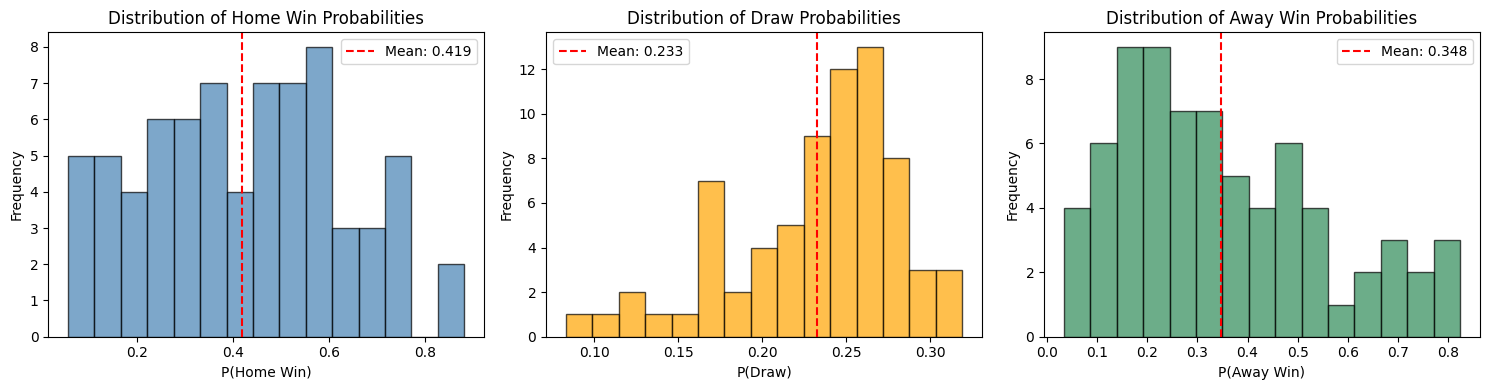

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(predictions['p_home_win'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('P(Home Win)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Home Win Probabilities')
axes[0].axvline(predictions['p_home_win'].mean(), color='red', linestyle='--', label=f"Mean: {predictions['p_home_win'].mean():.3f}")
axes[0].legend()

axes[1].hist(predictions['p_draw'], bins=15, color='orange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('P(Draw)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Draw Probabilities')
axes[1].axvline(predictions['p_draw'].mean(), color='red', linestyle='--', label=f"Mean: {predictions['p_draw'].mean():.3f}")
axes[1].legend()

axes[2].hist(predictions['p_away_win'], bins=15, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('P(Away Win)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Away Win Probabilities')
axes[2].axvline(predictions['p_away_win'].mean(), color='red', linestyle='--', label=f"Mean: {predictions['p_away_win'].mean():.3f}")
axes[2].legend()

plt.tight_layout()
plt.savefig('../results/01_probability_distributions.png', dpi=300, bbox_inches='tight')
print("Saved: 01_probability_distributions.png")
plt.show()

## 2. Group-by-Group Summary

Saved: 02_group_summary.png


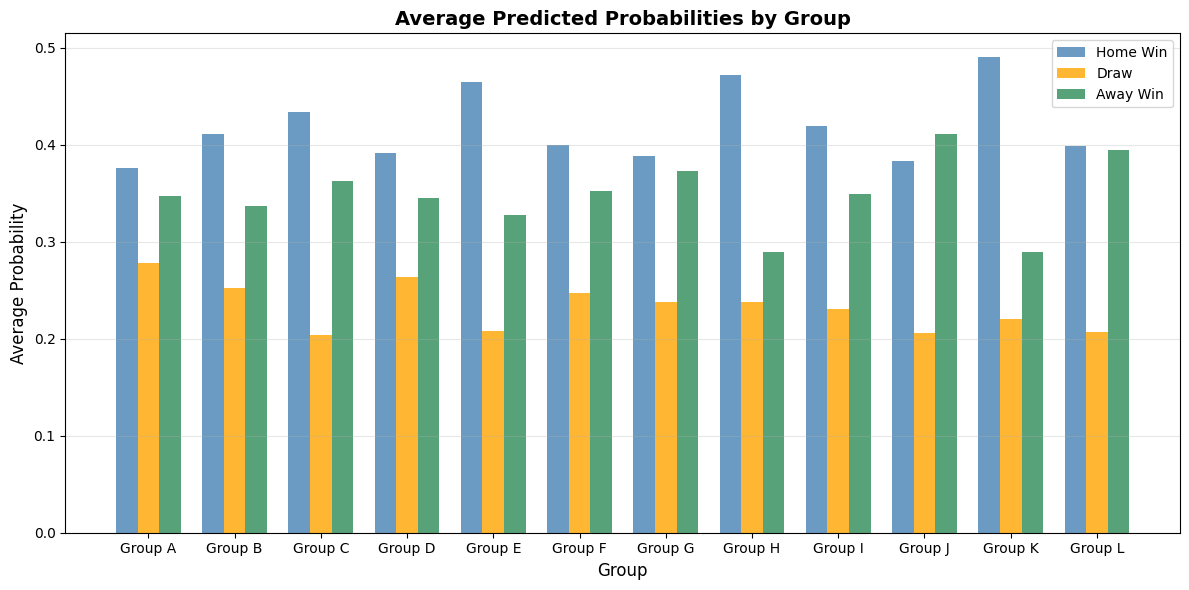


Average probabilities by group:
         p_home_win  p_draw  p_away_win
group                                  
Group A       0.376   0.278       0.347
Group B       0.411   0.253       0.337
Group C       0.434   0.204       0.362
Group D       0.391   0.264       0.345
Group E       0.465   0.208       0.327
Group F       0.400   0.248       0.353
Group G       0.389   0.238       0.373
Group H       0.472   0.238       0.290
Group I       0.420   0.231       0.349
Group J       0.384   0.206       0.410
Group K       0.490   0.220       0.290
Group L       0.399   0.206       0.395


In [3]:
# Compute average probabilities by group
group_stats = predictions.groupby('group')[['p_home_win', 'p_draw', 'p_away_win']].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(group_stats))
width = 0.25

ax.bar(x - width, group_stats['p_home_win'], width, label='Home Win', color='steelblue', alpha=0.8)
ax.bar(x, group_stats['p_draw'], width, label='Draw', color='orange', alpha=0.8)
ax.bar(x + width, group_stats['p_away_win'], width, label='Away Win', color='seagreen', alpha=0.8)

ax.set_xlabel('Group', fontsize=12)
ax.set_ylabel('Average Probability', fontsize=12)
ax.set_title('Average Predicted Probabilities by Group', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(group_stats.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/02_group_summary.png', dpi=300, bbox_inches='tight')
print("Saved: 02_group_summary.png")
plt.show()

print("\nAverage probabilities by group:")
print(group_stats.round(3))

## 3. Match Competitiveness Heatmap

Saved: 03_match_competitiveness.png


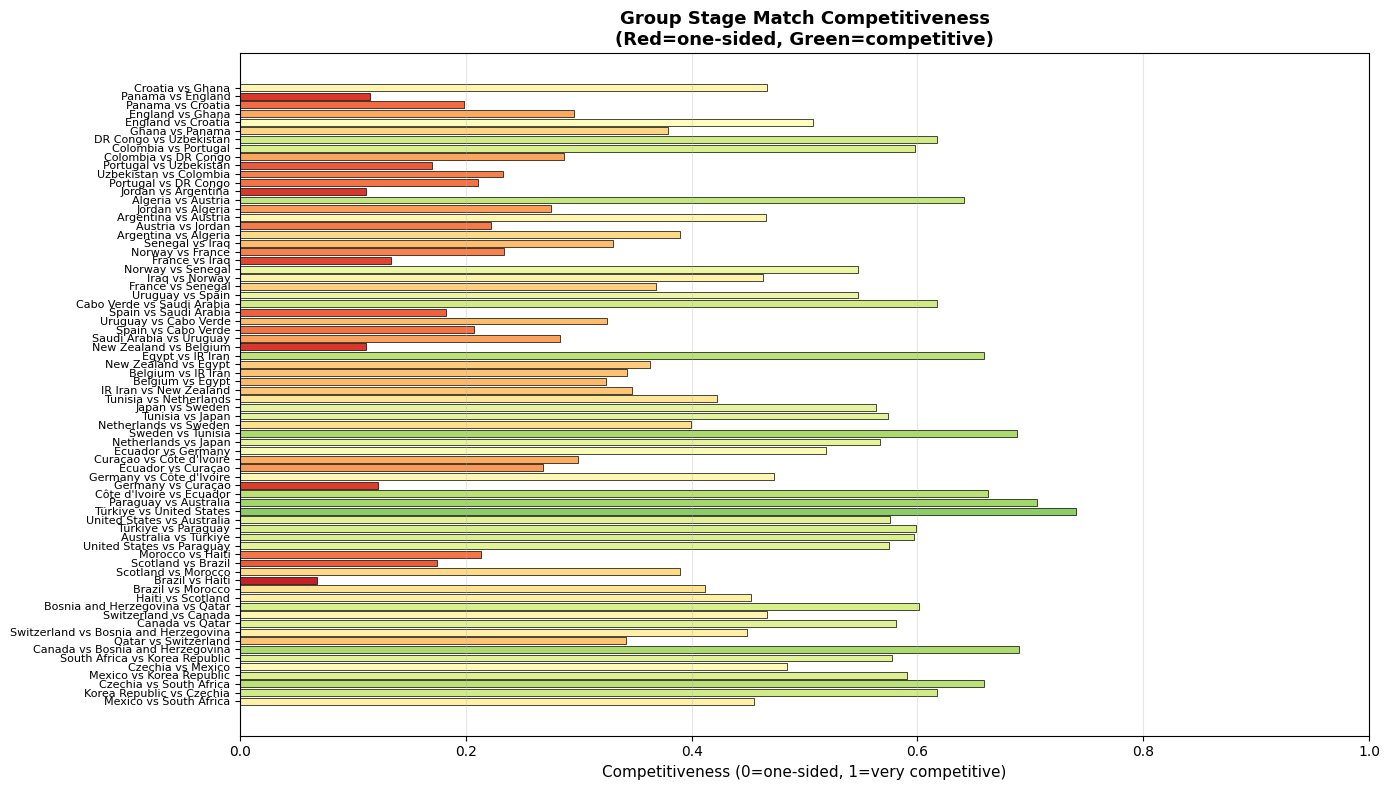


Most competitive matches:
          date      home_team               away_team  p_home_win    p_draw  \
58  2026-06-25        Türkiye           United States    0.370338  0.248963   
59  2026-06-25       Paraguay               Australia    0.360508  0.286371   
2   2026-06-12         Canada  Bosnia and Herzegovina    0.364318  0.290907   
11  2026-06-14         Sweden                 Tunisia    0.344179  0.290220   
8   2026-06-14  Côte d'Ivoire                 Ecuador    0.331195  0.290031   

    p_away_win  competitiveness  
58    0.380698         0.740676  
59    0.353121         0.706243  
2     0.344775         0.689550  
11    0.365601         0.688357  
8     0.378774         0.662390  

Most one-sided matches:
          date    home_team  away_team  p_home_win    p_draw  p_away_win  \
28  2026-06-19       Brazil      Haiti    0.882098  0.083073    0.034209   
69  2026-06-27       Jordan  Argentina    0.055683  0.125045    0.819162   
63  2026-06-26  New Zealand    Belgium   

In [4]:
# Calculate "competitiveness" of each match as min(p_home_win, p_away_win) * 2
# Close to 1.0 = very competitive, close to 0 = very one-sided
predictions['competitiveness'] = np.minimum(predictions['p_home_win'], predictions['p_away_win']) * 2

fig, ax = plt.subplots(figsize=(14, 8))

# Create a simple heatmap-like visualization
match_data = predictions[['date', 'group', 'home_team', 'away_team', 'competitiveness']].copy()
match_data['match'] = match_data['home_team'] + ' vs ' + match_data['away_team']

# Sort by group and date
match_data = match_data.sort_values(['group', 'date']).reset_index(drop=True)

# Create color map based on competitiveness
colors = plt.cm.RdYlGn(match_data['competitiveness'])

y_pos = np.arange(len(match_data))
ax.barh(y_pos, match_data['competitiveness'], color=colors, edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(match_data['match'], fontsize=8)
ax.set_xlabel('Competitiveness (0=one-sided, 1=very competitive)', fontsize=11)
ax.set_title('Group Stage Match Competitiveness\n(Red=one-sided, Green=competitive)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/03_match_competitiveness.png', dpi=300, bbox_inches='tight')
print("Saved: 03_match_competitiveness.png")
plt.show()

print(f"\nMost competitive matches:")
print(predictions.nlargest(5, 'competitiveness')[['date', 'home_team', 'away_team', 'p_home_win', 'p_draw', 'p_away_win', 'competitiveness']])
print(f"\nMost one-sided matches:")
print(predictions.nsmallest(5, 'competitiveness')[['date', 'home_team', 'away_team', 'p_home_win', 'p_draw', 'p_away_win', 'competitiveness']])

## 4. Predicted Winners by Group

In [5]:
# Show all groups with their predictions
for group in sorted(predictions['group'].unique()):
    group_matches = predictions[predictions['group'] == group].sort_values('date')
    print(f"\n{'='*80}")
    print(f"{group} MATCHES")
    print(f"{'='*80}")
    
    for _, row in group_matches.iterrows():
        home = row['home_team']
        away = row['away_team']
        p_h = row['p_home_win']
        p_d = row['p_draw']
        p_a = row['p_away_win']
        winner = row['predicted_winner']
        scoreline = row['top_scoreline']
        
        # Format the output nicely
        print(f"{row['date']} | {home:20s} {p_h:5.1%} vs {p_d:5.1%} vs {p_a:5.1%} {away:20s}  →  Predict: {winner:20s} ({scoreline})")


Group A MATCHES
2026-06-11 | Mexico               49.4% vs 27.8% vs 22.8% South Africa          →  Predict: Mexico               (1-0)
2026-06-12 | Korea Republic       42.1% vs 27.1% vs 30.8% Czechia               →  Predict: Korea Republic       (1-1)
2026-06-18 | Czechia              35.8% vs 31.2% vs 32.9% South Africa          →  Predict: Czechia              (1-0)
2026-06-18 | Mexico               44.9% vs 25.5% vs 29.5% Korea Republic        →  Predict: Mexico               (1-1)
2026-06-24 | Czechia              24.2% vs 26.4% vs 49.4% Mexico                →  Predict: Mexico               (0-1)
2026-06-24 | South Africa         28.9% vs 28.6% vs 42.5% Korea Republic        →  Predict: Korea Republic       (0-1)

Group B MATCHES
2026-06-12 | Canada               36.4% vs 29.1% vs 34.5% Bosnia and Herzegovina  →  Predict: Canada               (1-1)
2026-06-13 | Qatar                17.1% vs 20.3% vs 62.6% Switzerland           →  Predict: Switzerland          (0-2)
2026-06-18 |

## 5. Key Matchups (Major Teams)

Saved: 04_key_matchups.png


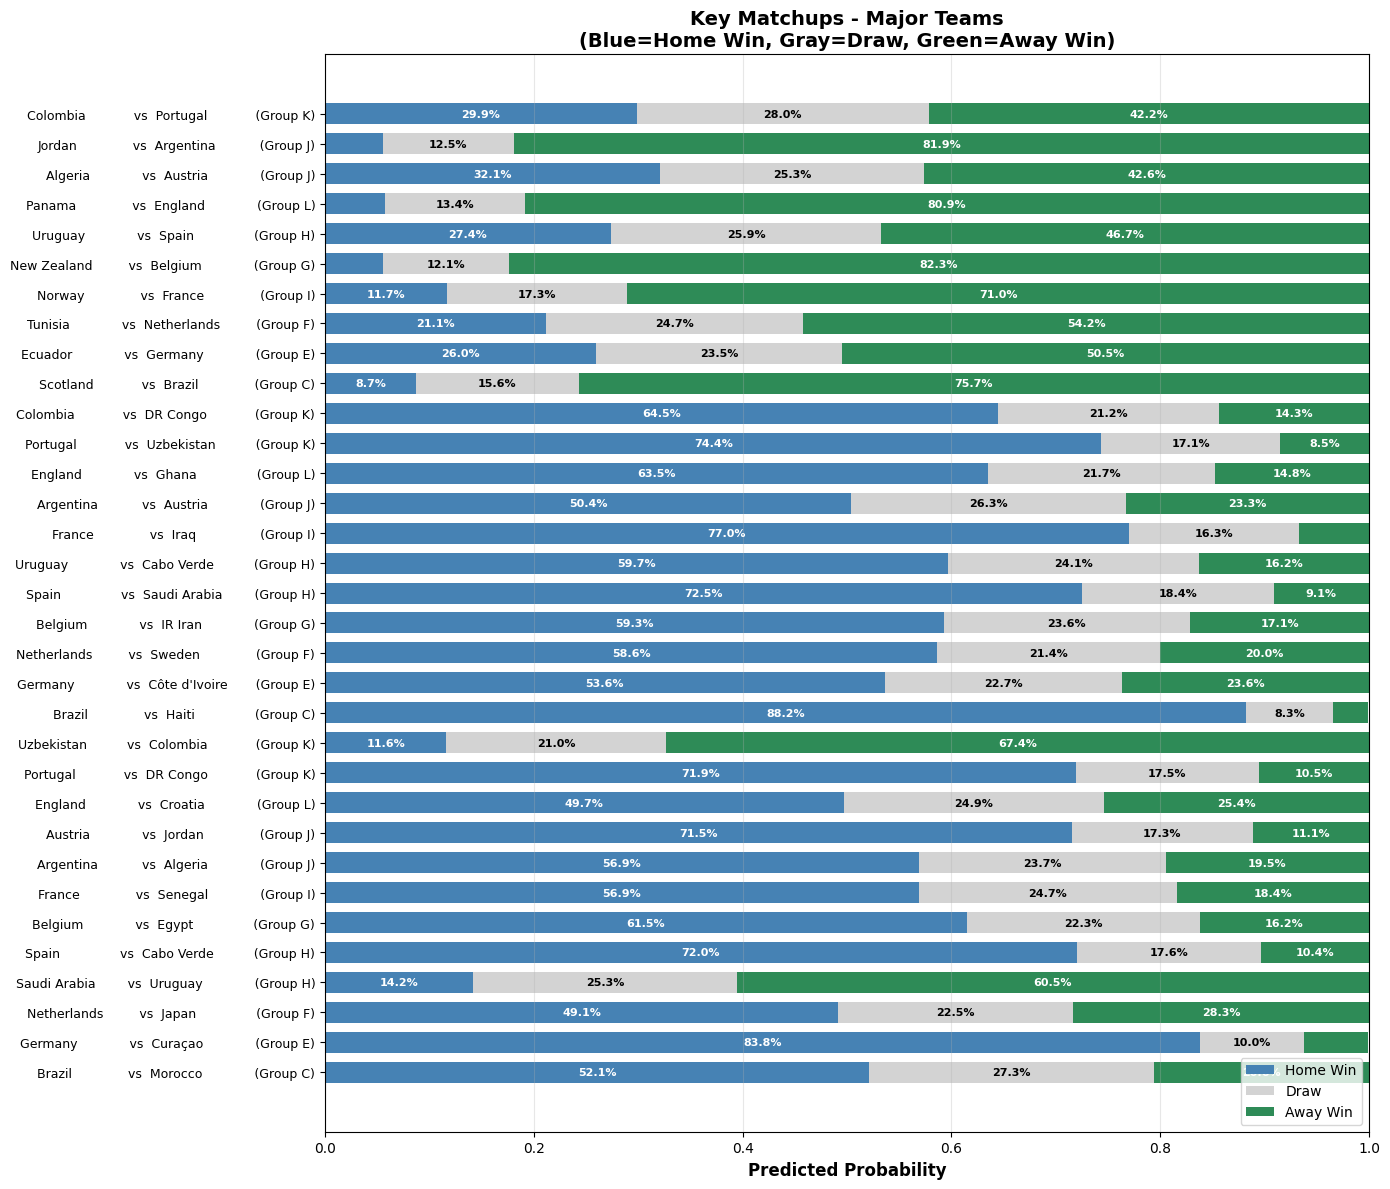


KEY MATCHUPS - MAJOR TEAMS
2026-06-13 | Group C  | Brazil               (52.1%) vs (20.6%) Morocco               →  Brazil
2026-06-14 | Group E  | Germany              (83.8%) vs (6.1%) Curaçao               →  Germany
2026-06-14 | Group F  | Netherlands          (49.1%) vs (28.3%) Japan                 →  Netherlands
2026-06-15 | Group H  | Saudi Arabia         (14.2%) vs (60.5%) Uruguay               →  Uruguay
2026-06-15 | Group H  | Spain                (72.0%) vs (10.4%) Cabo Verde            →  Spain
2026-06-15 | Group G  | Belgium              (61.5%) vs (16.2%) Egypt                 →  Belgium
2026-06-16 | Group I  | France               (56.9%) vs (18.4%) Senegal               →  France
2026-06-16 | Group J  | Argentina            (56.9%) vs (19.5%) Algeria               →  Argentina
2026-06-16 | Group J  | Austria              (71.5%) vs (11.1%) Jordan                →  Austria
2026-06-17 | Group L  | England              (49.7%) vs (25.4%) Croatia               →  England
2

In [6]:
major_teams = ['France', 'Brazil', 'Argentina', 'Germany', 'Spain', 'England', 'Belgium', 'Netherlands', 
               'Portugal', 'Austria', 'Colombia', 'Uruguay']

major_matches = predictions[
    (predictions['home_team'].isin(major_teams)) | 
    (predictions['away_team'].isin(major_teams))
].sort_values('date').reset_index(drop=True)

# Create visualization
fig, ax = plt.subplots(figsize=(14, 12))

y_positions = np.arange(len(major_matches))
match_labels = []

for idx, (_, row) in enumerate(major_matches.iterrows()):
    home = row['home_team']
    away = row['away_team']
    p_h = row['p_home_win']
    p_d = row['p_draw']
    p_a = row['p_away_win']
    
    # Stack bars: home win | draw | away win
    ax.barh(idx, p_h, color='steelblue', height=0.7, label='Home Win' if idx == 0 else '')
    ax.barh(idx, p_d, left=p_h, color='lightgray', height=0.7, label='Draw' if idx == 0 else '')
    ax.barh(idx, p_a, left=p_h+p_d, color='seagreen', height=0.7, label='Away Win' if idx == 0 else '')
    
    # Add probability labels on the bars
    if p_h > 0.08:
        ax.text(p_h/2, idx, f'{p_h:.1%}', va='center', ha='center', fontsize=8, fontweight='bold', color='white')
    if p_d > 0.08:
        ax.text(p_h + p_d/2, idx, f'{p_d:.1%}', va='center', ha='center', fontsize=8, fontweight='bold', color='black')
    if p_a > 0.08:
        ax.text(p_h + p_d + p_a/2, idx, f'{p_a:.1%}', va='center', ha='center', fontsize=8, fontweight='bold', color='white')
    
    # Create match label
    match_labels.append(f"{home:18s}  vs  {away:18s}  ({row['group']})")

ax.set_yticks(y_positions)
ax.set_yticklabels(match_labels, fontsize=9)
ax.set_xlabel('Predicted Probability', fontsize=12, fontweight='bold')
ax.set_title('Key Matchups - Major Teams\n(Blue=Home Win, Gray=Draw, Green=Away Win)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../results/04_key_matchups.png', dpi=300, bbox_inches='tight')
print("Saved: 04_key_matchups.png")
plt.show()

# Also print text summary
print("\n" + "="*100)
print("KEY MATCHUPS - MAJOR TEAMS")
print("="*100)
for _, row in major_matches.iterrows():
    home = row['home_team']
    away = row['away_team']
    p_h = row['p_home_win']
    p_d = row['p_draw']
    p_a = row['p_away_win']
    winner = row['predicted_winner']
    print(f"{row['date']} | {row['group']:8s} | {home:20s} ({p_h:.1%}) vs ({p_a:.1%}) {away:20s}  →  {winner}")

## 6. Summary Statistics

In [7]:
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print(f"\nTotal matches: {len(predictions)}")
print(f"\nPredicted winners distribution:")
print(predictions['predicted_winner'].value_counts().sort_index())

print(f"\nProbability statistics:")
print(f"\nHome Win:")
print(f"  Mean: {predictions['p_home_win'].mean():.3f}")
print(f"  Median: {predictions['p_home_win'].median():.3f}")
print(f"  Std: {predictions['p_home_win'].std():.3f}")
print(f"  Min: {predictions['p_home_win'].min():.3f}")
print(f"  Max: {predictions['p_home_win'].max():.3f}")

print(f"\nDraw:")
print(f"  Mean: {predictions['p_draw'].mean():.3f}")
print(f"  Median: {predictions['p_draw'].median():.3f}")
print(f"  Std: {predictions['p_draw'].std():.3f}")
print(f"  Min: {predictions['p_draw'].min():.3f}")
print(f"  Max: {predictions['p_draw'].max():.3f}")

print(f"\nAway Win:")
print(f"  Mean: {predictions['p_away_win'].mean():.3f}")
print(f"  Median: {predictions['p_away_win'].median():.3f}")
print(f"  Std: {predictions['p_away_win'].std():.3f}")
print(f"  Min: {predictions['p_away_win'].min():.3f}")
print(f"  Max: {predictions['p_away_win'].max():.3f}")

print(f"\nCompetitiveness:")
print(f"  Mean: {predictions['competitiveness'].mean():.3f}")
print(f"  Median: {predictions['competitiveness'].median():.3f}")


SUMMARY STATISTICS

Total matches: 72

Predicted winners distribution:
predicted_winner
Algeria                   1
Argentina                 3
Austria                   2
Belgium                   3
Bosnia and Herzegovina    1
Brazil                    3
Cabo Verde                1
Canada                    2
Colombia                  2
Croatia                   2
Czechia                   1
Côte d'Ivoire             1
DR Congo                  1
Ecuador                   2
Egypt                     1
England                   3
France                    3
Germany                   3
Ghana                     1
IR Iran                   2
Japan                     2
Korea Republic            2
Mexico                    3
Morocco                   2
Netherlands               3
Norway                    1
Paraguay                  1
Portugal                  3
Scotland                  1
Senegal                   2
Spain                     3
Switzerland               3
Tunisia        